# Semantic Search: A Comparative Evaluation of BM25, SBERT and SPLADE

**Course:** CAS Deep Learning @ FHNW / Advanced NLP Project  
**Benchmark:** BEIR (Benchmarking IR)  
**Dataset:** MS MARCO (dev split)  
**Configuration:** 100 queries · 10 000 corpus documents

**Author:** Korhan Gülseven  
**Date:** April 2026


---

## 1 Introduction
Information retrieval (IR) is the task of finding relevant documents for a given query.
Traditional approaches rely on **lexical matching**, a document is relevant if it shares exact terms with the query.
Modern **neural** methods instead learn dense or sparse representations that capture meaning, allowing them to bridge the **vocabulary mismatch problem** (e.g., matching climate/weather or car/automobile).

This notebook evaluates three retrieval paradigms on the same benchmark:

- **BM25** · Lexical (Handcrafted sparse)  
Scores documents by weighted term overlap. A word is more important to a document the more frequently it appears in it, but the more rarely it occurs across all documents overall.

- **SBERT** · Learned dense  
Instead of matching exact words, dense retrieval encodes the meaning of queries and documents into embeddings. Documents whose meaning is close to the query's meaning end up nearby in vector space and can be found via simple (cosine) similarity comparison, even if they use completely different words.

- **SPLADE** · Learned sparse  
Uses a masked language model to predict importance weights for words, including words not literally present in the text. The resulting sparse representations could in principle be searched via inverted indexes, but this notebook uses dense matrix similarity for simplicity. Unlike SBERT, SPLADE maintains word-level granularity rather than compressing meaning into a single vector.

All three are evaluated on the same queries, corpus, and ground truth labels using the [BEIR](https://github.com/beir-cellar/beir) framework, making results directly comparable.

### 1.1 Objective

**How do lexical (BM25), learned-dense (SBERT), and learned-sparse (SPLADE) retrieval methods compare on standard IR metrics when evaluated on the same MS MARCO subset?**

We additionally perform a qualitative case study with a custom query that requires *semantic* understanding to retrieve the correct document.

---
## 2 Setup & Configuration


### 2.1 Imports and GPU requirements
⚠️ GPU Requirement: SPLADE encoding with a corpus size of 10'000 documents requires significant GPU memory. A T4 (15 GB) may run into OOM errors, a L4 (24 GB) or higher is recommended. Set your runtime via Runtime → Change runtime type → L4 GPU before executing the notebook. Also note the batch sizes of 128 in the SPLADE implementation below.

In [1]:
# ── Install dependencies (uncomment if running for the first time) ──
!pip install beir sentence-transformers matplotlib pandas numpy ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.8/304.8 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 117.2 MB/s eta 0:00:00


In [2]:
import json, math, re, time, warnings
from collections import defaultdict, Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.ticker as mticker

from beir import util
from beir.datasets.data_loader import GenericDataLoader
from beir.retrieval.evaluation import EvaluateRetrieval
from beir.retrieval import models
from beir.retrieval.search.dense import DenseRetrievalExactSearch as DRES
from sentence_transformers import SentenceTransformer, SparseEncoder

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

print('All imports successful.')

/usr/local/lib/python3.12/dist-packages/beir/util.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


All imports successful.


In [3]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    free, total = torch.cuda.mem_get_info(0)
    print(f'VRAM: {free/1e9:.1f} GB frei / {total/1e9:.1f} GB gesamt')

PyTorch device: cuda
GPU: NVIDIA L4
VRAM: 23.5 GB frei / 23.7 GB gesamt


### 2.2 Hugging Face Token
SPLADE implementation uses "naver/splade-v3", which is a gated model on Hugging Face. Access requires accepting the license on the model page and authenticating with a valid token.

In [4]:
from huggingface_hub import login
from getpass import getpass
login(token=getpass("HF Token: "))

HF Token: ··········


### 2.3 Timer Decorator

In [5]:
def timer(func):
    """Measures and prints execution time of a function."""
    def wrapper(*args, **kwargs):
        start = time.perf_counter()
        result = func(*args, **kwargs)
        duration = time.perf_counter() - start
        cls_name = args[0].__class__.__name__ + '.' if args else ''
        print(f'{cls_name}{func.__name__}: {duration:.4f}s')
        return result
    return wrapper

---
### 2.4 Configuration

In [6]:
from dataclasses import dataclass
from google.colab import drive

# Mount Google Drive, which we will use to cache the downloaded dataset
# Uncomment this if you want the data to be persisted across multiple colab sessions

drive.mount('/content/drive')

@dataclass(slots=True)
class DatasetConfig:
    """Which BEIR split to load and how much to keep."""
    max_queries: int
    max_corpus: int
    name: str = 'msmarco'
    dir: str = '../datasets'
    split: str = 'dev'
    download_url: str = (
        'https://public.ukp.informatik.tu-darmstadt.de'
        '/thakur/BEIR/datasets/{dataset}.zip'.format(dataset='msmarco')
    )

@dataclass(slots=True)
class PreprocessingConfig:
    """How BEIR document fields are merged before retrieval."""
    include_title: bool = True
    separator: str = '\n\n'

# Settings ──
DATASET_CFG = DatasetConfig(max_queries=100, max_corpus=10_000, dir='/content/drive/MyDrive/datasets')
PREPROC_CFG = PreprocessingConfig()
K_VALUES = [1, 3, 5, 10, 100]

print(f'Dataset : {DATASET_CFG.name} ({DATASET_CFG.split})')
print(f'Queries : {DATASET_CFG.max_queries}')
print(f'Corpus  : {DATASET_CFG.max_corpus}')

Mounted at /content/drive
Dataset : msmarco (dev)
Queries : 100
Corpus  : 10000


---
## 3 Dataset: BEIR / MS MARCO

[MS MARCO](https://microsoft.github.io/msmarco/) is a large-scale reading comprehension and IR dataset.
BEIR wraps it into a standardised format with three components:

- **Corpus** — documents (each with `title` + `text`)
- **Queries** — natural-language questions
- **Qrels** — relevance judgements mapping `(query_id, doc_id) → relevance`

### 3.1 Preprocessing

In [7]:
def fix_encoding(text: str) -> str:
    """Fix Latin-1 / UTF-8 double-encoding."""
    try:
        return text.encode('latin-1').decode('utf-8')
    except (UnicodeDecodeError, UnicodeEncodeError):
        return text


def build_document_text(document, include_title=True, separator='\n\n'):
    """Join BEIR title and body fields into one text string."""
    title = fix_encoding((document.get('title') or '').strip())
    text  = fix_encoding((document.get('text')  or '').strip())
    if include_title and title and text:
        return f'{title}{separator}{text}'
    return title if (include_title and title) else text


def cap_mapping(items, limit):
    """Trim a mapping deterministically to `limit` entries."""
    if limit is None:
        return dict(items)
    return dict(list(items.items())[:limit])


def preprocess_dataset(corpus, queries, qrels, config):
    """Cap queries, keep relevant docs, fill with distractors up to max_corpus."""
    capped_queries = cap_mapping(queries, config.max_queries)

    filtered_qrels = {qid: rels for qid, rels in qrels.items() if qid in capped_queries}

    required_doc_ids = set()
    for rels in filtered_qrels.values():
        required_doc_ids.update(rels.keys())

    capped_corpus = {did: corpus[did] for did in required_doc_ids if did in corpus}

    # Fill with distractors
    if config.max_corpus and len(capped_corpus) < config.max_corpus:
        for doc_id, doc in corpus.items():
            if doc_id not in capped_corpus:
                capped_corpus[doc_id] = doc
                if len(capped_corpus) >= config.max_corpus:
                    break

    filtered_qrels   = {qid: rels for qid, rels in filtered_qrels.items() if rels}
    filtered_queries  = {qid: capped_queries[qid] for qid in filtered_qrels}

    print(f'Preprocessed → corpus: {len(capped_corpus)}, '
          f'queries: {len(filtered_queries)}, qrels: {len(filtered_qrels)}')
    return capped_corpus, filtered_queries, filtered_qrels

### 3.2 Loader & Caching

In [8]:
def get_cache_dir(config):
    return Path(config.dir) / f'{config.name}_cached_{config.max_queries}_{config.max_corpus}'


def cache_exists(cache_dir):
    return all((cache_dir / f).exists() for f in ['corpus.jsonl', 'queries.jsonl', 'qrels.json'])


def save_cache(cache_dir, corpus, queries, qrels):
    """# Save dataset to local cache so we don't need to re-download it every session."""
    cache_dir.mkdir(parents=True, exist_ok=True)
    with open(cache_dir / 'corpus.jsonl', 'w') as f:
        for doc_id, doc in corpus.items():
            f.write(json.dumps({'_id': doc_id, **doc}) + '\n')
    with open(cache_dir / 'queries.jsonl', 'w') as f:
        for qid, text in queries.items():
            f.write(json.dumps({'_id': qid, 'text': text}) + '\n')
    with open(cache_dir / 'qrels.json', 'w') as f:
        json.dump(qrels, f)


def load_cache(cache_dir):
    """Load corpus, queries and qrels from cached JSONL/JSON files."""
    corpus, queries = {}, {}
    with open(cache_dir / 'corpus.jsonl') as f:
        for line in f:
            obj = json.loads(line); doc_id = obj.pop('_id'); corpus[doc_id] = obj
    with open(cache_dir / 'queries.jsonl') as f:
        for line in f:
            obj = json.loads(line); queries[obj['_id']] = obj['text']
    with open(cache_dir / 'qrels.json') as f:
        qrels = json.load(f)
    return corpus, queries, qrels


def load_dataset(dataset_config, preprocessing_config):
    """Load BEIR dataset from cache or download, preprocess, and return query/corpus splits."""
    cache_dir = get_cache_dir(dataset_config)
    if cache_exists(cache_dir):
        print(f'Loading from cache: {cache_dir}')
        corpus, queries, qrels = load_cache(cache_dir)
    else:
        path = Path(dataset_config.dir); path.mkdir(parents=True, exist_ok=True)
        dataset_dir = path / dataset_config.name
        if not (dataset_dir.exists() and any(dataset_dir.iterdir())):
            util.download_and_unzip(dataset_config.download_url, str(path))
        corpus, queries, qrels = GenericDataLoader(str(dataset_dir)).load(split=dataset_config.split)
        corpus, queries, qrels = preprocess_dataset(corpus, queries, qrels, dataset_config)
        save_cache(cache_dir, corpus, queries, qrels)

    corpus_texts = {
        doc_id: build_document_text(doc, preprocessing_config.include_title, preprocessing_config.separator)
        for doc_id, doc in corpus.items()
    }
    print(f'Loaded → Queries: {len(queries)}, Qrels: {len(qrels)}, Corpus: {len(corpus_texts)}')
    return queries, qrels, corpus_texts

Now load the dataset: Downloads and preprocesses it on first run, uses cache (Google Drive or Colab storage) thereafter.

In [9]:
queries, qrels, corpus_texts = load_dataset(DATASET_CFG, PREPROC_CFG)

Loading from cache: /content/drive/MyDrive/datasets/msmarco_cached_100_10000
Loaded → Queries: 100, Qrels: 100, Corpus: 10000


### 3.3 Exploratory Data Analysis

In [10]:
print('── Sample Queries ──')
for i, (qid, q) in enumerate(queries.items()):
    print(f'  [{qid}] {q}')
    if i >= 4: break

print(f'\n── Sample Document ──')
sample_id = list(corpus_texts.keys())[0]
print(f'  [{sample_id}] {corpus_texts[sample_id][:300]}…')

doc_lengths = [len(t.split()) for t in corpus_texts.values()]
print(f'\n── Corpus Statistics ──')
print(f'  Documents  : {len(corpus_texts)}')
print(f'  Avg length : {np.mean(doc_lengths):.0f} words')
print(f'  Med length : {np.median(doc_lengths):.0f} words')
print(f'  Min / Max  : {min(doc_lengths)} / {max(doc_lengths)} words')

── Sample Queries ──
  [300674] how many years did william bradford serve as governor of plymouth colony?
  [125705] define preventive
  [94798] color overlay photoshop
  [9083] ____________________ is considered the father of modern medicine.
  [174249] does xpress bet charge to deposit money in your account

── Sample Document ──
  [7072326] Depending on the particular form, the government generally carries out the desires of the people. Popular forms of government, including democracies and republics, come from the governments of the Romans and the Greeks. The government's job is to determine and implement policy or principles to get a…

── Corpus Statistics ──
  Documents  : 10000
  Avg length : 53 words
  Med length : 49 words
  Min / Max  : 3 / 211 words


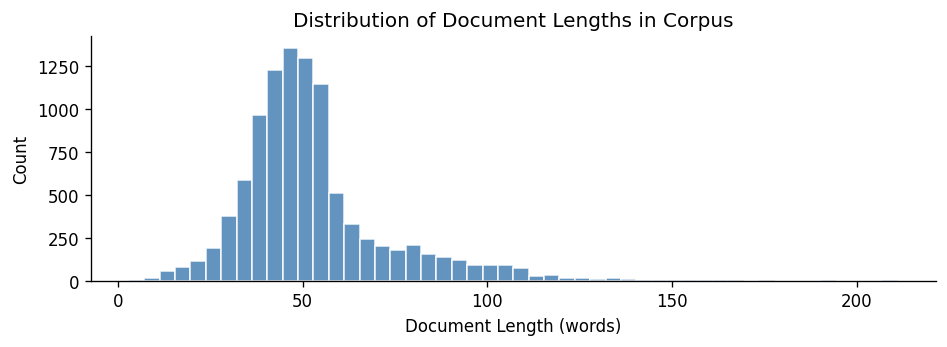

In [11]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(doc_lengths, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_xlabel('Document Length (words)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Document Lengths in Corpus')
plt.tight_layout()
plt.show()

---
## 4 Methods

### 4.1 Evaluation Metrics

All three methods are evaluated with the same metrics at $k \in \{1, 3, 5, 10, 100\}$:

| Metric | What it Measures |
|--------|------------------|
| **nDCG@k** | Cares about where the relevant results appear. Finding a relevant document at position 1 is worth more than finding it at position 10. <br>A perfect score means all relevant documents are ranked at the top in the best possible order. |
| **MAP@k** | Averages precision at each point where a relevant document is found. If you have 3 relevant docs and find them at positions 1, 3, and 9, <br>each of those positions gets a precision score, then they're averaged. Rewards systems that find relevant documents early and consistently. |
| **Recall@k** | Of all relevant documents that exist, what fraction did you find in your top-k? A recall@10 of 0.8 means you found 80% <br>of the relevant documents in your first 10 results. Doesn't care about ordering. |
| **Precision@k** | The inverse question: of your k returned results, how many are actually relevant? A precision@10 of 0.6 means 6 <br>out of your 10 results are relevant. Doesn't care about what you missed. |

We use BEIR's `EvaluateRetrieval` for consistent, comparable evaluation across all methods.

**Side Note: Why Do "Searcy", "Climate", and "Weather" keep showing up again and again?** These are terms appearing across example queries and documents to demonstrate how different retrieval methods (BM25, SBERT, SPLADE) handle exact matching, semantic understanding, and term expansion, E.g. linking "Searcy" to "Arkansas" without an explicit mention (Searcy is a city in Arkansas).

### 4.2 Method 1 — BM25 (Lexical Baseline)

BM25 (*Best Matching 25*) is a probabilistic ranking function from the TF-IDF family. BM25 scores a document by asking three things for each query term:

1. Is the word rare? Terms that appear in fewer documents get a higher weight (IDF).
2. How often does it appear? More occurrences increase the score, but the effect saturates, each additional mention contributes less (controlled by k1​).
3. Is the document short? A match in a short document counts more than the same match in a long one (controlled by b).  

The final score sums these contributions across all query terms.

**Key property:** BM25 can only match on *exact terms*. If the query says *"climate"* but the document says *"weather"*, BM25 assigns a score of zero for that term.

#### 4.2.1 Implementation

In [12]:
STOPWORDS = {
    'a','an','the','and','or','but','if','then','else','for','of','on','in','to',
    'with','by','from','at','as','is','are','was','were','be','been','being',
    'have','has','had','do','does','did','this','that','these','those','it','its',
    'he','she','they','them','his','her','their','we','us','our','you','your',
    'i','me','my','not','no','can','could','should','would','may','might','must',
    'will','just'
}

def tokenize(text, remove_stopwords=True):
    """Split text into lowercase tokens, optionally removing stopwords."""
    words = re.findall(r'\b\w+\b', text.lower())
    if remove_stopwords:
        words = [w for w in words if w not in STOPWORDS]
    return words


class BM25:

    @timer
    def __init__(self, corpus_texts, k1=1.5, b=0.75):
        self.k1 = k1  # term frequency saturation
        self.b  = b   # document length normalization

        self.doc_ids = list(corpus_texts.keys())
        self.tokenized_docs = [tokenize(corpus_texts[did]) for did in self.doc_ids]

        self.term_freqs = []
        self.doc_lengths = []
        self.doc_freq = defaultdict(int)

        for tokens in self.tokenized_docs:
            counts = Counter(tokens)
            self.term_freqs.append(counts)
            self.doc_lengths.append(len(tokens))
            for term in counts:
                self.doc_freq[term] += 1

        self.num_docs = len(self.tokenized_docs)

        # Avg document length: reference point for length normalization
        self.avg_doc_length = sum(self.doc_lengths) / self.num_docs

        # Rare terms get high weight: (N - df) / df
        self.idf = {
            term: math.log(1 + (self.num_docs - df + 0.5) / (df + 0.5))
            for term, df in self.doc_freq.items()
        }


    def scores(self, queries):
        return {qid: self.score(q) for qid, q in queries.items()}


    def score(self, query, explain=False):
        query_terms = tokenize(query)
        scores, explanations = {}, {}

        for idx, doc_id in enumerate(self.doc_ids):
            doc_score = 0.0
            doc_terms = self.term_freqs[idx]
            doc_len = self.doc_lengths[idx]
            term_details = {}

            for term in query_terms:
                if term not in doc_terms:
                  continue

                freq = doc_terms[term]
                rarity = self.idf.get(term, 0)

                # Length normalization: long docs are penalized, short docs boosted
                # Saturation: diminishing returns for repeated terms
                norm = freq + self.k1 * (1 - self.b + self.b * doc_len / self.avg_doc_length)

                # Final score per term: rarity × saturated frequency
                term_score = rarity * (freq * (self.k1 + 1)) / norm

                doc_score += term_score
                if explain:
                  term_details[term] = {'tf': freq, 'idf': rarity, 'score': term_score}

            scores[doc_id] = doc_score
            if explain:
              explanations[doc_id] = term_details

        return (scores, explanations) if explain else scores


    def top_sorted(self, scores, top=10):
        return sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top]


    def evaluate(self, qrels, results, k_values=None):
        return EvaluateRetrieval().evaluate(qrels, results, k_values or K_VALUES)

#### 4.2.2 Indexing & Retrieval

In [13]:
bm25 = BM25(corpus_texts)

BM25.__init__: 0.3535s


In [14]:
results_bm25 = bm25.scores(queries)

#### 4.2.3 Evaluation

In [15]:
ndcg_bm25, map_bm25, recall_bm25, precision_bm25 = bm25.evaluate(qrels, results_bm25)

print('── BM25 Results ──')
for name, d in [('nDCG', ndcg_bm25), ('MAP', map_bm25),
                ('Recall', recall_bm25), ('Precision', precision_bm25)]:
    print(f'  {name}: { {k: round(v, 4) for k, v in d.items()} }')

── BM25 Results ──
  nDCG: {'NDCG@1': 0.82, 'NDCG@3': 0.8464, 'NDCG@5': 0.8632, 'NDCG@10': 0.8833, 'NDCG@100': 0.8887}
  MAP: {'MAP@1': 0.7883, 'MAP@3': 0.8383, 'MAP@5': 0.8478, 'MAP@10': 0.8566, 'MAP@100': 0.8573}
  Recall: {'Recall@1': 0.7883, 'Recall@3': 0.865, 'Recall@5': 0.905, 'Recall@10': 0.965, 'Recall@100': 0.995}
  Precision: {'P@1': 0.82, 'P@3': 0.31, 'P@5': 0.194, 'P@10': 0.103, 'P@100': 0.0106}


### 4.3 Method 2 — SBERT (Dense Neural Retrieval)

Sentence-BERT uses a bi-encoder architecture: queries and documents are independently mapped to dense vectors by the same transformer. Relevance is measured via cosine similarity, which captures how closely two vectors point in the same direction. A score of 1 means identical meaning, 0 means unrelated. Because document representations are pre-computed, retrieval reduces to a matrix multiplication, making it efficient even for large corpora. The model used here is [all-MiniLM-L6-v2](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2), which is fast and memory-efficient for our purposes (384-dim embeddings).

**Key property:** SBERT captures *semantic meaning*, so it can match *"climate"* to *"weather"* even without any shared tokens.

#### 4.3.1 Implementation

In [16]:
class SBert:

    @timer
    def __init__(self, corpus_texts, model_name='all-MiniLM-L6-v2'):
        self.doc_ids = list(corpus_texts.keys())
        dense_retrieval = DRES(models.SentenceBERT(model_name), batch_size=256)
        self.sbert = dense_retrieval.model.q_model
        self.doc_embeddings = self.sbert.encode(
            list(corpus_texts.values()),
            convert_to_numpy=True, normalize_embeddings=True, batch_size=256
        )
        print(f'doc_embeddings.shape: {self.doc_embeddings.shape}')
        self.beir = EvaluateRetrieval(dense_retrieval, score_function='cos_sim')


    def scores(self, queries):
        qids = list(queries.keys())
        qe = self.sbert.encode(list(queries.values()),
                               convert_to_numpy=True, normalize_embeddings=True)
        qe = np.atleast_2d(qe)
        sim = self.doc_embeddings @ qe.T
        return {qid: dict(zip(self.doc_ids, sim[:, i].tolist()))
                for i, qid in enumerate(qids)}


    def score(self, query):
        return self.scores({'q': query})['q']


    def top_sorted(self, scores, top=10):
        return sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top]


    def evaluate(self, qrels, results, k_values=None):
        return self.beir.evaluate(qrels, results, k_values=k_values or K_VALUES)

#### 4.3.2 Encoding & Retrieval

In [17]:
sbert = SBert(corpus_texts)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

doc_embeddings.shape: (10000, 384)
SBert.__init__: 17.3584s


In [18]:
results_sbert = sbert.scores(queries)

#### 4.3.3 Evaluation

In [19]:
ndcg_sbert, map_sbert, recall_sbert, precision_sbert = sbert.evaluate(qrels, results_sbert)

print('── SBERT Results ──')
for name, d in [('nDCG', ndcg_sbert), ('MAP', map_sbert),
                ('Recall', recall_sbert), ('Precision', precision_sbert)]:
    print(f'  {name}: { {k: round(v, 4) for k, v in d.items()} }')

── SBERT Results ──
  nDCG: {'NDCG@1': 0.95, 'NDCG@3': 0.9626, 'NDCG@5': 0.9669, 'NDCG@10': 0.9701, 'NDCG@100': 0.9717}
  MAP: {'MAP@1': 0.9183, 'MAP@3': 0.96, 'MAP@5': 0.9625, 'MAP@10': 0.9637, 'MAP@100': 0.9639}
  Recall: {'Recall@1': 0.9183, 'Recall@3': 0.97, 'Recall@5': 0.98, 'Recall@10': 0.99, 'Recall@100': 1.0}
  Precision: {'P@1': 0.95, 'P@3': 0.3467, 'P@5': 0.21, 'P@10': 0.106, 'P@100': 0.0107}


### 4.4 Method 3 — SPLADE (Learned Sparse Retrieval)

SPLADE (SParse Lexical AnD Expansion) uses a masked language model (e.g., BERT / DistilBERT) to compute importance weights for every token in the vocabulary. The result is a sparse vector of the same dimensionality as the vocabulary (english ~30k), most weights are zero, only a few terms get meaningful scores. The model assigns high weights to important terms and performs term expansion by producing non-zero weights for semantically related terms not present in the text. For example, a document about "Searcy" may receive a non-zero weight for "Arkansas" even if that word never appears. This bridges the vocabulary mismatch problem of pure lexical methods like BM25, while keeping the efficiency of sparse retrieval.

**Key property:** SPLADE combines the *efficiency* of sparse retrieval (inverted index compatible)
with the *semantic understanding* of neural models. The model used here is [naver/splade-v3](https://huggingface.co/naver/splade-v3).

#### 4.4.1 Implementation

In [20]:
class Splade:

    @timer
    def __init__(self, corpus_texts, model_name='naver/splade-v3'):
        self.doc_ids = list(corpus_texts.keys())
        self.model = SparseEncoder(model_name)
        self.doc_embeddings = self.model.encode_document(
            list(corpus_texts.values()), batch_size=128
        )
        print(f'doc_embeddings.shape: {self.doc_embeddings.shape}')


    def scores(self, queries):
        qids = list(queries.keys())
        qv = self.model.encode_query(
            list(queries.values()), batch_size=128
        )
        sim = self.model.similarity(qv, self.doc_embeddings)
        return {qid: dict(zip(self.doc_ids, sim[i].tolist()))
                for i, qid in enumerate(qids)}


    def score(self, query):
        return self.scores({'q': query})['q']


    def top_sorted(self, scores, top=10):
        return sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top]


    def evaluate(self, qrels, results, k_values=None):
        return EvaluateRetrieval().evaluate(qrels, results, k_values or K_VALUES)


    def explain(self, query, doc_text, top_k=15):
      # Run query and document through SPLADE → one sparse vector each (~30k dimensions).
      query_vec = self.model.encode_query([query])[0].to_dense().cpu()
      doc_vec = self.model.encode_document([doc_text])[0].to_dense().cpu()

      # Reverse-Lookup token-id -> word
      vocab = self.model.tokenizer.get_vocab()
      id_to_token = {v: k for k, v in vocab.items()}

      # Extract non-zero values
      query_terms = {id_to_token[i.item()]: query_vec[i].item() for i in query_vec.nonzero().squeeze()}
      doc_terms = {id_to_token[i.item()]: doc_vec[i].item() for i in doc_vec.nonzero().squeeze()}

      # only terms that are non-zero in both vectors. Score contribution = query_weight × doc_weight
      overlap = {t: query_terms[t] * doc_terms[t] for t in query_terms if t in doc_terms}

      return sorted(overlap.items(), key=lambda x: -x[1])[:top_k]


#### 4.4.2 Encoding & Retrieval

In [21]:
splade = Splade(corpus_texts)

modules.json:   0%|          | 0.00/274 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/274 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/682 [00:00<?, ?B/s]

...

Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 116, in auto_conversion
    raise e
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 95, in auto_conversion
    sha = get_conversion_pr_reference(api, pretrained_model_name_or_path, **cached_file_kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 76, in get_conversion_pr_reference
    raise OSError(
OSError: Could not create safetensors conversion PR. The repo does not appear to have a file named pytorch_model.bin or model.safetensors.

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

doc_embeddings.shape: torch.Size([10000, 30522])
Splade.__init__: 55.4851s


In [22]:
results_splade = splade.scores(queries)

#### 4.4.3 Evaluation

In [23]:
ndcg_splade, map_splade, recall_splade, precision_splade = splade.evaluate(qrels, results_splade)

print('── SPLADE Results ──')
for name, d in [('nDCG', ndcg_splade), ('MAP', map_splade),
                ('Recall', recall_splade), ('Precision', precision_splade)]:
    print(f'  {name}: { {k: round(v, 4) for k, v in d.items()} }')

── SPLADE Results ──
  nDCG: {'NDCG@1': 0.98, 'NDCG@3': 0.9863, 'NDCG@5': 0.9863, 'NDCG@10': 0.9899, 'NDCG@100': 0.9899}
  MAP: {'MAP@1': 0.9483, 'MAP@3': 0.985, 'MAP@5': 0.985, 'MAP@10': 0.9867, 'MAP@100': 0.9867}
  Recall: {'Recall@1': 0.9483, 'Recall@3': 0.99, 'Recall@5': 0.99, 'Recall@10': 1.0, 'Recall@100': 1.0}
  Precision: {'P@1': 0.98, 'P@3': 0.3533, 'P@5': 0.212, 'P@10': 0.107, 'P@100': 0.0107}


---
## 5 Analysis & Results

### 5.1 Visualization Helpers

In [24]:
def plot_beir_metrics(results, k_values):
    """
    Multi-line chart for IR metrics over k-values.
    results: {'ModelName': {'NDCG': {...}, 'Recall': {...}, 'MAP': {...}, 'P': {...}}, ...}
    """
    metrics = ['NDCG', 'Recall', 'MAP', 'P']
    colors  = ['#3266ad', '#c0392b', '#27ae60', '#8e44ad', '#e67e22']
    styles  = ['-', '--', '-.', ':']

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for ax, metric in zip(axes.flatten(), metrics):
        for i, (model, model_results) in enumerate(results.items()):
            scores = [model_results[metric].get(f'{metric}@{k}', 0) for k in k_values]
            ax.plot(k_values, scores, marker='o', label=model,
                    color=colors[i % len(colors)],
                    linestyle=styles[i % len(styles)], linewidth=2)
        ax.set_title(metric, fontsize=13)
        ax.set_xlabel('k'); ax.set_ylabel('Score')
        ax.set_xticks(k_values); ax.set_xscale('log')
        ax.xaxis.set_major_formatter(mticker.ScalarFormatter())

        # Zoom into relevant scale
        all_scores = [
          model_results[metric].get(f'{metric}@{k}', 0)
          for model_results in results.values()
          for k in k_values
        ]
        y_min = max(0, min(all_scores) - 0.05)
        ax.set_ylim(y_min, 1.02)
        ax.legend(fontsize=9)

    fig.suptitle('IR Evaluation Metrics', fontsize=15, y=1.01)
    plt.tight_layout()
    plt.show()


def plot_topk_comparison(query, topk_bm25, topk_sbert, topk_splade, texts):
    """Side-by-side bar chart comparing BM25, SBERT & SPLADE top-k for a single query."""
    all_sets = [set(d for d, _ in t) for t in [topk_bm25, topk_sbert, topk_splade]]
    common = all_sets[0] & all_sets[1] & all_sets[2]
    k = max(len(topk_bm25), len(topk_sbert), len(topk_splade))
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, max(3, k * 0.5)))
    for ax, data, title, c_def, xlabel in [
        (ax1, topk_bm25, 'BM25 (raw score)', 'steelblue', 'BM25 Score'),
        (ax2, topk_sbert, 'SBERT', 'indianred', 'Cosine Similarity'),
        (ax3, topk_splade, 'SPLADE', 'darkorchid', 'SPLADE Score'),
    ]:
        doc_ids = [d for d, _ in data]
        scores  = [s for _, s in data]
        colors  = ['mediumseagreen' if d in common else c_def for d in doc_ids]
        labels  = [f'{d}: {texts[d][:40]}…' for d in doc_ids]
        bars = ax.barh(range(len(scores)), scores, color=colors)
        ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8)
        ax.invert_yaxis(); ax.set_xlabel(xlabel); ax.set_title(title)
        ax.bar_label(bars, fmt='%.2f', padding=4, fontsize=8)
    fig.suptitle(f"Query: '{query}'\nGreen = in all three top-{k}", fontsize=11)
    plt.tight_layout(); plt.show()


def plot_metrics_at_k(results, k=10):
    """Grouped bar chart comparing all models at a specific k value."""
    metrics = ['NDCG', 'MAP', 'Recall']
    models  = list(results.keys())
    colors  = ['#3266ad', '#c0392b', '#27ae60']
    x = np.arange(len(metrics))
    width = 0.22

    fig, ax = plt.subplots(figsize=(8, 5))
    for i, model in enumerate(models):
        values = [results[model][m].get(f'{m}@{k}', 0) for m in metrics]
        bars = ax.bar(x + i * width, values, width, label=model, color=colors[i])
        ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)

    ax.set_xticks(x + width); ax.set_xticklabels(metrics, fontsize=12)
    ax.set_ylabel('Score'); ax.set_ylim(0.75, 1.02)
    ax.set_title(f'Model Comparison at k={k}', fontsize=14)
    ax.legend(fontsize=10)
    plt.tight_layout(); plt.show()

### 5.1 Results Overview

In [25]:
all_results = {
    'BM25':   {'NDCG': ndcg_bm25,   'MAP': map_bm25,   'Recall': recall_bm25,   'P': precision_bm25},
    'SBERT':  {'NDCG': ndcg_sbert,  'MAP': map_sbert,  'Recall': recall_sbert,  'P': precision_sbert},
    'SPLADE': {'NDCG': ndcg_splade, 'MAP': map_splade, 'Recall': recall_splade, 'P': precision_splade},
}

# Build summary table
rows = []
for model, metrics in all_results.items():
    row = {'Model': model}
    for metric_name, values in metrics.items():
        for k, v in values.items():
            row[k] = round(v, 4)
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index('Model')
summary_df.style.highlight_max(axis=0, color='#d4edda')

,NDCG@1,NDCG@3,NDCG@5,NDCG@10,NDCG@100,MAP@1,MAP@3,MAP@5,MAP@10,MAP@100,Recall@1,Recall@3,Recall@5,Recall@10,Recall@100,P@1,P@3,P@5,P@10,P@100
Model,,,,,,,,,,,,,,,,,,,,
BM25,0.820000,0.846400,0.863200,0.883300,0.888700,0.788300,0.838300,0.847800,0.856600,0.857300,0.788300,0.865000,0.905000,0.965000,0.995000,0.820000,0.310000,0.194000,0.103000,0.010600
SBERT,0.950000,0.962600,0.966900,0.970100,0.971700,0.918300,0.960000,0.962500,0.963700,0.963900,0.918300,0.970000,0.980000,0.990000,1.000000,0.950000,0.346700,0.210000,0.106000,0.010700
SPLADE,0.980000,0.986300,0.986300,0.989900,0.989900,0.948300,0.985000,0.985000,0.986700,0.986700,0.948300,0.990000,0.990000,1.000000,1.000000,0.980000,0.353300,0.212000,0.107000,0.010700


Note: All scores are relatively high (>0.82 across all) due to the small subset size (100 queries, 10k corpus). On the full MS MARCO dataset, absolute values would be lower and the gaps between methods more pronounced.

**BM25:** Solid baseline with NDCG@1 of 0.82 -> exact term matching works well for many queries, but BM25 struggles when query and document use different words for the same concept, which shows in the lower recall at small k. This is where SBERT and SPLADE will pull ahead.

**SBERT:** An increase of NDCG@1 to 0.95: Semantic understanding catches what BM25 misses (eg. matching "weather" to "climate"). Higher Recall@1 and Recall@100 reaches 1.0, meaning it eventually finds every relevant document, even when surface terms don't overlap.

**SPLADE:** Best overall with NDCG@1 of 0.98! The jump from SBERT's 0.95 shows that combining exact lexical matching with semantic term expansion outperforms pure semantic similarity. It benefits from both exact matches and expanded terms like "Searcy" → "Arkansas". Recall@10 already reaches 1.0, meaning every relevant document is found within the top 10 results.


### 5.2 Metrics over k

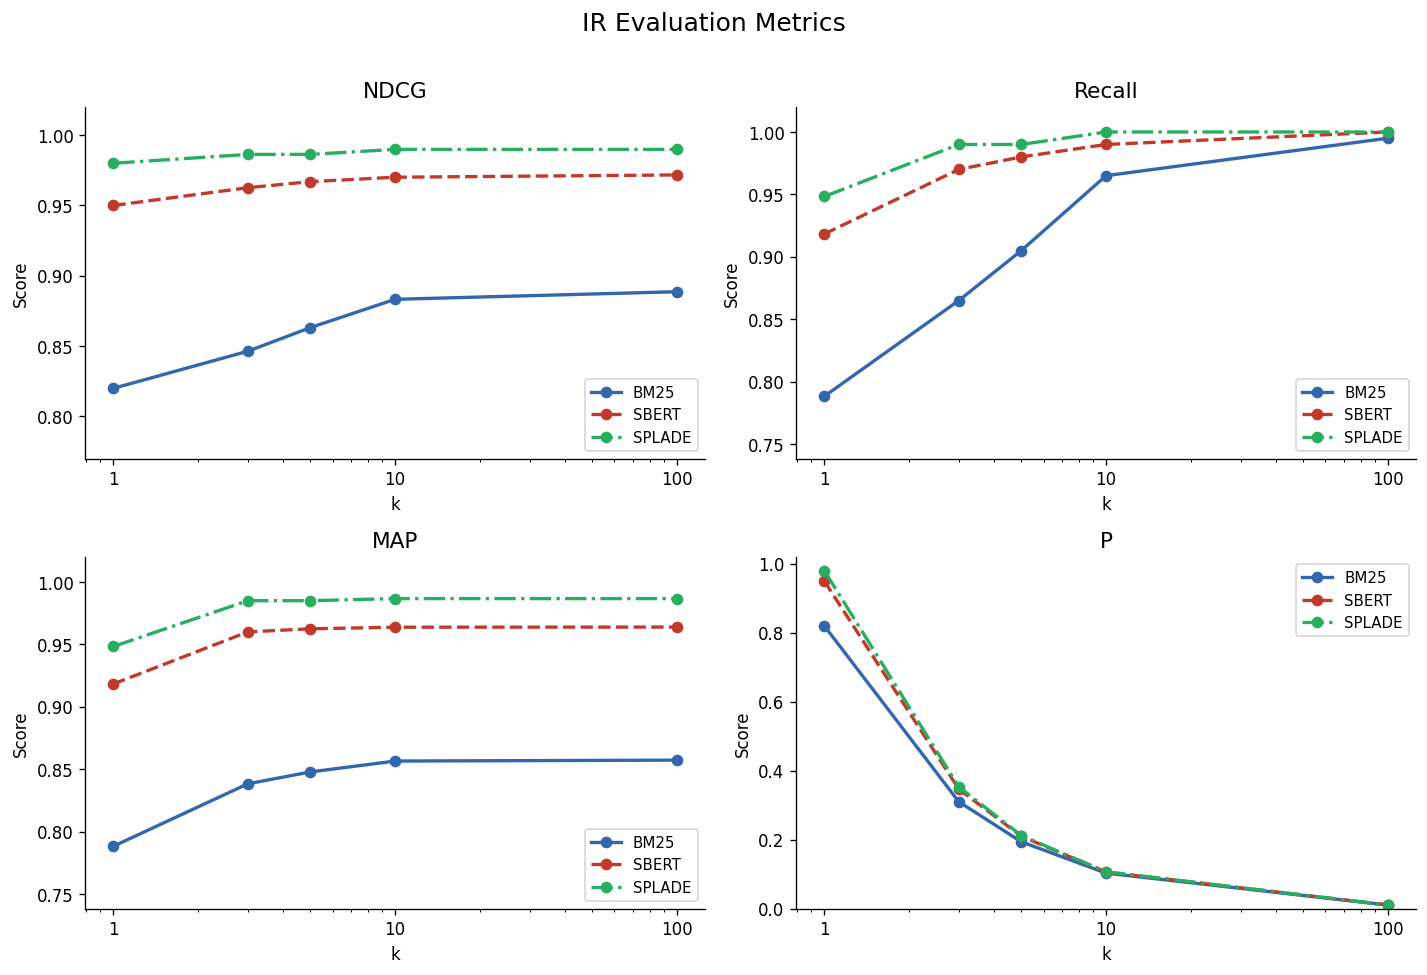

In [26]:
plot_beir_metrics(all_results,  k_values=[1, 3, 5, 10, 100])

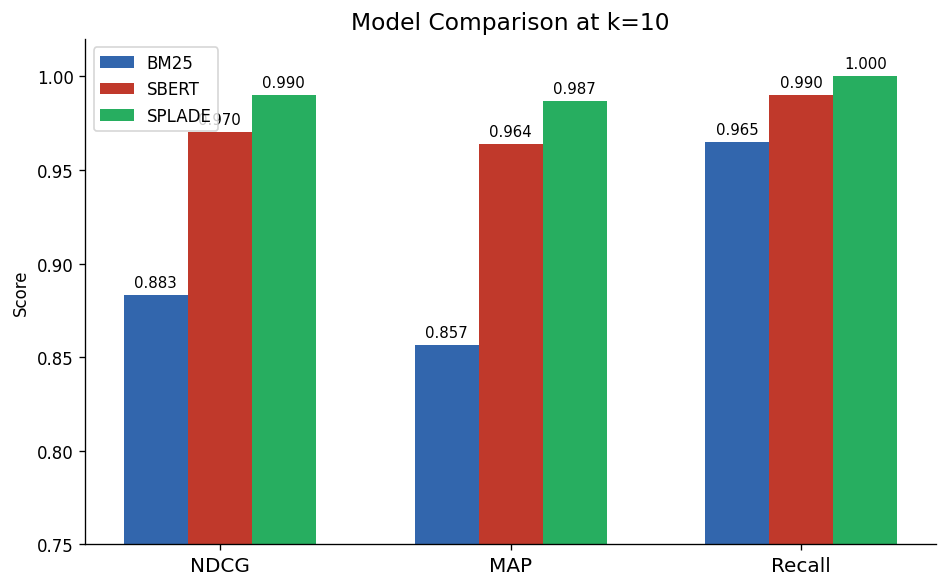

In [27]:
plot_metrics_at_k(all_results, k=10)

---
## 6 Case Study: Custom Query

To illustrate the **vocabulary mismatch problem**, we test a query that requires
semantic understanding to retrieve the correct document.

> **Query:** *"What is the climate like in Searcy"*

A document about Searcy, Arkansas may mention *"humid subtropical"*, *"hot summers"*, or
*"mild winters"* — none of which share tokens with *"climate"*. BM25 can only match if
the exact word appears, while SBERT and SPLADE can bridge this gap.

In [28]:
QUERY_SEARCY = 'What is the climate like in Searcy'

### 6.1 BM25 - Custom Query

In [29]:
scores_bm25_searcy, explanations = bm25.score(QUERY_SEARCY, explain=True)
top5_bm25_searcy = bm25.top_sorted(scores_bm25_searcy, 5)

print(f"Query: '{QUERY_SEARCY}'\n")
for rank, (doc_id, score) in enumerate(top5_bm25_searcy, 1):
    print(f'#{rank}  {doc_id}  (score: {score:.4f})')
    print(f'    {corpus_texts[doc_id][:100]}…')
    for term, vals in explanations[doc_id].items():
        print(f'    {term:<20} tf={vals["tf"]:>3}  idf={vals["idf"]:.4f}  score={vals["score"]:.4f}')
    print()

Query: 'What is the climate like in Searcy'

#1  4734  (score: 12.2681)
    The sun is out and shining and we are waiting for you! CABO SAN LUCAS CLIMATE INFORMATION. Cabo San …
    what                 tf=  1  idf=2.7358  score=2.4618
    climate              tf=  2  idf=5.3289  score=7.0520
    like                 tf=  1  idf=3.0609  score=2.7543

#2  3001  (score: 11.2956)
    Worldwide zones of tropical monsoon climate (Am). Tropical monsoon climate, occasionally also known …
    climate              tf= 14  idf=5.3289  score=11.2956

#3  2455  (score: 11.0412)
    Seville has a subtropical Mediterranean climate (Koeppen köppen climate Classification). Csa like Mo…
    climate              tf=  2  idf=5.3289  score=7.8468
    like                 tf=  1  idf=3.0609  score=3.1943

#4  7374  (score: 9.9205)
    The term climate change is often used to refer specifically to anthropogenic climate change (also kn…
    climate              tf=  5  idf=5.3289  score=9.9205

#5  7078754  

### 6.2 SBERT - Custom Query

In [30]:
scores_sbert_searcy = sbert.score(QUERY_SEARCY)
top5_sbert_searcy = sbert.top_sorted(scores_sbert_searcy, 5)

print(f"Query: '{QUERY_SEARCY}'\n")
for rank, (doc_id, score) in enumerate(top5_sbert_searcy, 1):
    print(f'#{rank}  {doc_id}  (score: {score:.4f})')
    print(f'    {corpus_texts[doc_id][:100]}…\n')

Query: 'What is the climate like in Searcy'

#1  7078754  (score: 0.8604)
    In Searcy, the summers are hot and muggy, the winters are very cold and wet, and it is partly cloudy…

#2  1445  (score: 0.4845)
    The Barnstable area is located on the mostly flat coastal plain of Cape Cod with beaches to the nort…

#3  903  (score: 0.4326)
    The Netherlands. 1  The Netherlands have a temperate maritime climate influenced by the North Sea an…

#4  2458  (score: 0.4297)
    The Seville harbour, located about 80 kilometres (50 miles) from the Atlantic Ocean, is the only riv…

#5  2455  (score: 0.4295)
    Seville has a subtropical Mediterranean climate (Koeppen köppen climate Classification). Csa like Mo…



### 6.3 SPLADE - Custom Query

In [31]:
scores_splade_searcy = splade.score(QUERY_SEARCY)
top5_splade_searcy = splade.top_sorted(scores_splade_searcy, 5)

print(f"Query: '{QUERY_SEARCY}'\n")
for rank, (doc_id, score) in enumerate(top5_splade_searcy, 1):
    print(f'#{rank}  {doc_id}  (score: {score:.4f})')
    print(f'    {corpus_texts[doc_id][:100]}…\n')
    for term, contrib in splade.explain(QUERY_SEARCY, corpus_texts[doc_id]):
      print(f'    {term:<20} contribution={contrib:.4f}')

Query: 'What is the climate like in Searcy'

#1  7078754  (score: 33.1338)
    In Searcy, the summers are hot and muggy, the winters are very cold and wet, and it is partly cloudy…

    ##rc                 contribution=6.9459
    sea                  contribution=6.0041
    weather              contribution=5.5197
    cool                 contribution=4.9484
    ##y                  contribution=3.3340
    climate              contribution=2.2019
    summer               contribution=1.0940
    maine                contribution=1.0541
    ireland              contribution=0.8252
    ##ry                 contribution=0.3280
    england              contribution=0.2707
    wales                contribution=0.1393
    canada               contribution=0.1151
    france               contribution=0.1122
    like                 contribution=0.0911
#2  901  (score: 19.1879)
    The Netherlands. The Netherlands have a temperate maritime climate influenced by the North Sea and A…

    climat

Let's break down SPLADE's top match:
- The WordPiece subwords for "Searcy" contribute heavily to the score (##rc, sea, ##y)
- "weather", "climate" and "cool" make up the other big part. Note that none of these words appear in the document, these are the result of semantic expansion, likely inferred from "hot and muggy", "very cold", "temperature"
- Interestingly, geographic terms like "maine", "ireland", "england" also show up, likely because the training data contains climate documents that frequently mention places.

In [32]:
doc_id_first_rank = top5_splade_searcy[0][0];
print(f"first rank ({doc_id_first_rank}): {corpus_texts[doc_id_first_rank]}")
for term, contrib in splade.explain(QUERY_SEARCY, corpus_texts[doc_id_first_rank]):
  print(f'    {term:<20} contribution={contrib:.4f}')
tokenizer = splade.model.tokenizer
print(f"Wordpiece subwords for Searcy: {tokenizer.tokenize('Searcy')}")

first rank (7078754): In Searcy, the summers are hot and muggy, the winters are very cold and wet, and it is partly cloudy year round. Over the course of the year, the temperature typically varies from 31°F to 92°F and is rarely below 18°F or above 100°F.
    ##rc                 contribution=6.9459
    sea                  contribution=6.0041
    weather              contribution=5.5197
    cool                 contribution=4.9484
    ##y                  contribution=3.3340
    climate              contribution=2.2019
    summer               contribution=1.0940
    maine                contribution=1.0541
    ireland              contribution=0.8252
    ##ry                 contribution=0.3280
    england              contribution=0.2707
    wales                contribution=0.1393
    canada               contribution=0.1151
    france               contribution=0.1122
    like                 contribution=0.0911
Wordpiece subwords for Searcy: ['sea', '##rc', '##y']


**Fall of BM25:** At this point, BM25 falls behind SBERT and SPLADE. Both SBERT and SPLADE return the correct document at rank #1. Let's look at a query where SPLADE beats SBERT.

In [33]:
QUERY_DRAGONS = "here there be dragons comic"
qid_dragons = [qid for qid, q in queries.items() if q == QUERY_DRAGONS][0]
print(f"Query: {QUERY_DRAGONS}")
print(f"Query ID: {qid_dragons}")
print(f"Relevant docs (qrels): {qrels[qid_dragons]}")
print("--------\n")

scores_sbert_dragons = sbert.score(QUERY_DRAGONS)
top3_sbert_dragons = sbert.top_sorted(scores_sbert_dragons, 3)
print(f"SBERT results:\n")
for rank, (doc_id, score) in enumerate(top3_sbert_dragons, 1):
    print(f'#{rank}  {doc_id}  (score: {score:.4f})')
    print(f'    {corpus_texts[doc_id]}…\n')

scores_splade_dragons = splade.score(QUERY_DRAGONS)
top3_splade_dragons = splade.top_sorted(scores_splade_dragons, 3)
print(f"SPLADE results:\n")
for rank, (doc_id, score) in enumerate(top3_splade_dragons, 1):
    print(f'#{rank}  {doc_id}  (score: {score:.4f})')
    print(f'    {corpus_texts[doc_id]}…\n')
    for term, contrib in splade.explain(QUERY_DRAGONS, corpus_texts[doc_id]):
      print(f'    {term:<20} contribution={contrib:.4f}')


Query: here there be dragons comic
Query ID: 201376
Relevant docs (qrels): {'7068066': 1}
--------

SBERT results:

#1  7437  (score: 0.4293)
    With the update of the Brimhaven dungeon came the next part in the dragon armour series: Dragon platelegs. Soon after came the next part of dragon armour; the Dragon plateskirt.…

#2  7068066  (score: 0.4266)
    James A. Owen is an American comic book illustrator, publisher and writer. He is known for his creator-owned comic book series Starchild and as the author of The Chronicles of the Imaginarium Geographica novel series, that began with Here, There Be Dragons in 2006. 1 Career.…

#3  6846  (score: 0.4086)
    A Dragon Scale is an item introduced in Generation II that evolves Seadra into Kingdra when held while being traded. This item cannot be bought, only found, but can be sold for 1050. In the Johto region games, this item can be found in Mt. Mortar and at the Pokéathlon Dome in Pokémon HeartGold and SoulSilver.…

SPLADE results:

#1 

SBERT ranks the correct document #2, overtaken by a Pokémon article that happens to mention "dragon", it can't recognize the query as a book title. SPLADE returns the correct document at #1 with high confidence, where "comic" contributes significantly as a lexical match alongside the title terms.

### 6.4 Side-by-Side Comparison

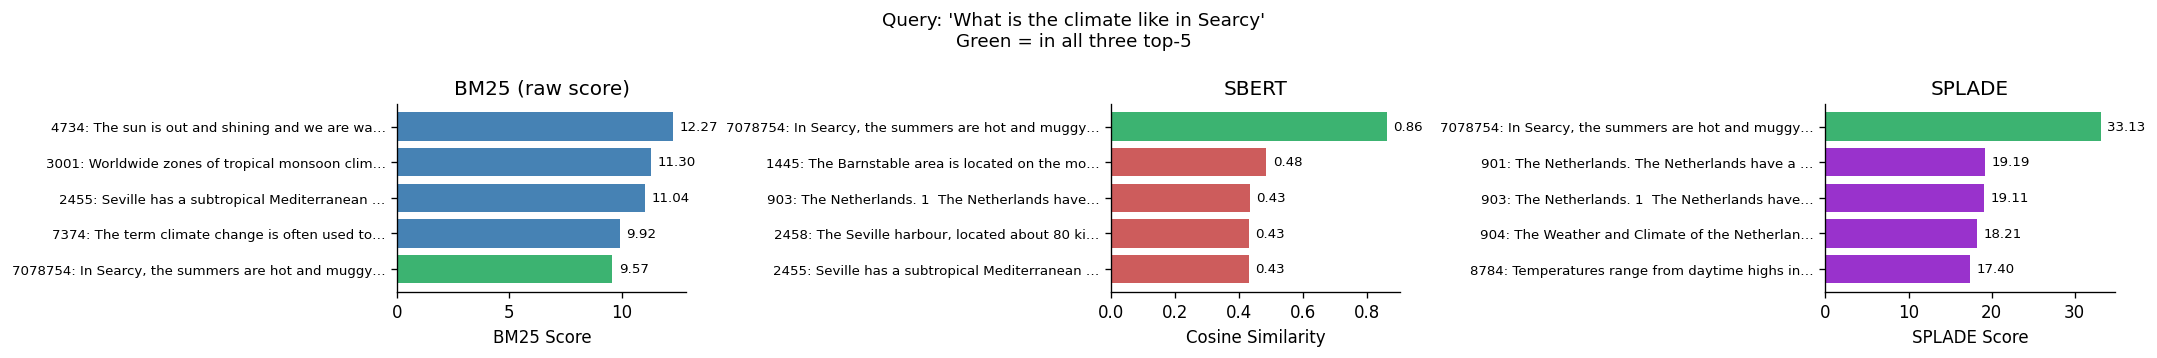

In [34]:
plot_topk_comparison(QUERY_SEARCY, top5_bm25_searcy, top5_sbert_searcy, top5_splade_searcy, corpus_texts)

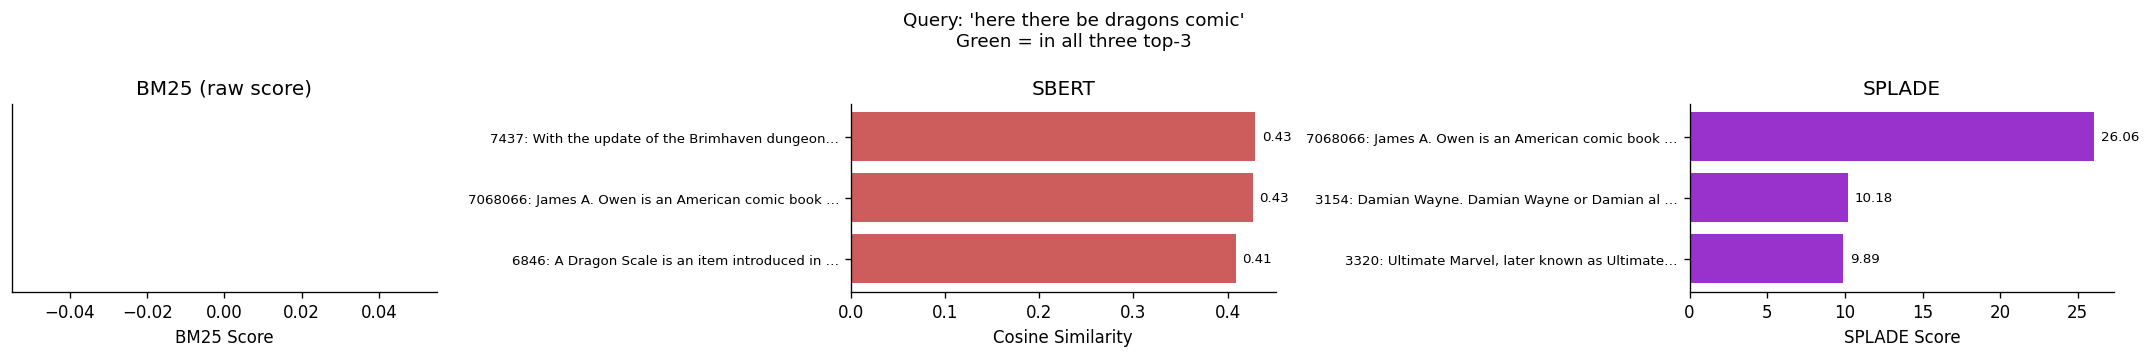

In [35]:
plot_topk_comparison(QUERY_DRAGONS, [], top3_sbert_dragons, top3_splade_dragons, corpus_texts)

---
## 7 Conclusion
- BM25 is fast and transparent, but limited to exact term matching. It fails when query and document use different words for the same concept.  
- SBERT and SPLADE both solve this through semantic understanding and achieve similar retrieval quality here. SPLADE edges ahead on some queries by combining lexical matching with term expansion, an advantage that would likely grow on larger corpora.  
- The big differentiator is explainability: SPLADE's sparse vectors reveal exactly which terms drive a match (including expanded ones), while SBERT's dense vectors are a black box. SPLADE also stays inverted-index-compatible, making it in producton deployments as efficient as BM25 at query time.  

|                            | BM25 | SBERT | SPLADE |
|:---------------------------|:----:|:-----:|:------:|
| Semantic understanding     |  no   |   yes   |   yes    |
| Explainability             |  yes   |   no   |   yes    |
| Inverted index compatible  |  yes   |   no   |   yes    |


---
## 8 Reflexion
This project was self-chosen, driven by my interest in semantic search. Working through the comparison of BM25, SBERT, and SPLADE using BEIR taught me a lot. Not just about the algorithms themselves, but about how to evaluate and interpret retrieval systems. The overall structure, the narrative thread across work packages, and the interpretation of results are my own work. Throughout the project, I used claude.ai as a learning companion: to deepen my understanding of unfamiliar concepts, to explore unclear topics, and to generate and troubleshoot python code.


---
## 9 References

1. Michael Brenndoerfer, [BM25: The Probabilistic Ranking Revolution in Information Retrieval](https://mbrenndoerfer.com/writing/bm25-probabilistic-ranking-information-retrieval)
2. Evan Schwartz, [Understanding the BM25 full text search algorithm](https://emschwartz.me/understanding-the-bm25-full-text-search-algorithm/)
3. Saketh Kotamraju, [An Intuitive Explanation of Sentence-BERT](https://towardsdatascience.com/an-intuitive-explanation-of-sentence-bert-1984d144a868/)
4. James Briggs, [SPLADE for Sparse Vector Search Explained](https://www.pinecone.io/learn/splade/)
5. Microsoft, [MS MARCO](https://microsoft.github.io/msmarco/)
6. 🤗, [Datasets/BeIR/msmarco](https://huggingface.co/datasets/BeIR/msmarco)